# Haldane Substrate Inhibition Kinetics

---


We will first look at the equation in isolation, as a (static) rate law. Later this rate law can be re-used in dynamical models for simulations. 

# Illustration of Function

In [11]:
from matplotlib.pyplot import figure
from matplotlib.colors import LinearSegmentedColormap

import numpy as np

## Rate function definition


In [12]:
def haldane_kinetics(S, k_max, K_m, k_i, m):
    """
    Hill kinetics equation; reduces to Michaelis-Menten for n=1
    
    S:     substrate concentration (typically a range of values expected)
    k_max: maximum reaction rate (includes enzyme concentration)
    K_m:   Michaelis constant (fixed at 1)
    n:     Hill coefficient (exponent of cooperativity, positive real number)
    """

    # rate = (k_max * S**n) / (K_m**n + S**n)
    rate = (k_max * S)    / (K_m + S + k_i * S**m)

    
    return rate


Here, you specify a range of substrate concentration and the three constants needed to evaluate the function. The function call will return a range of velocities corresponding to the substrate concentrations. 

## Call of the rate function and plot


Enzyme Kinetics without and with cooperativity
Parameters: k_max = 1, K_m = 1

Key observations:
1. n = 1: Classic hyperbolic Michaelis-Menten kinetics
2. n > 1: Positive cooperativity - sigmoidal curves
3. n >> 1: Switch-like behavior - very steep transition
5. Half-maximal rate at S = K_m = 1

 Change from hyperbolic (blue) to switch-like shape (orange, red)
 


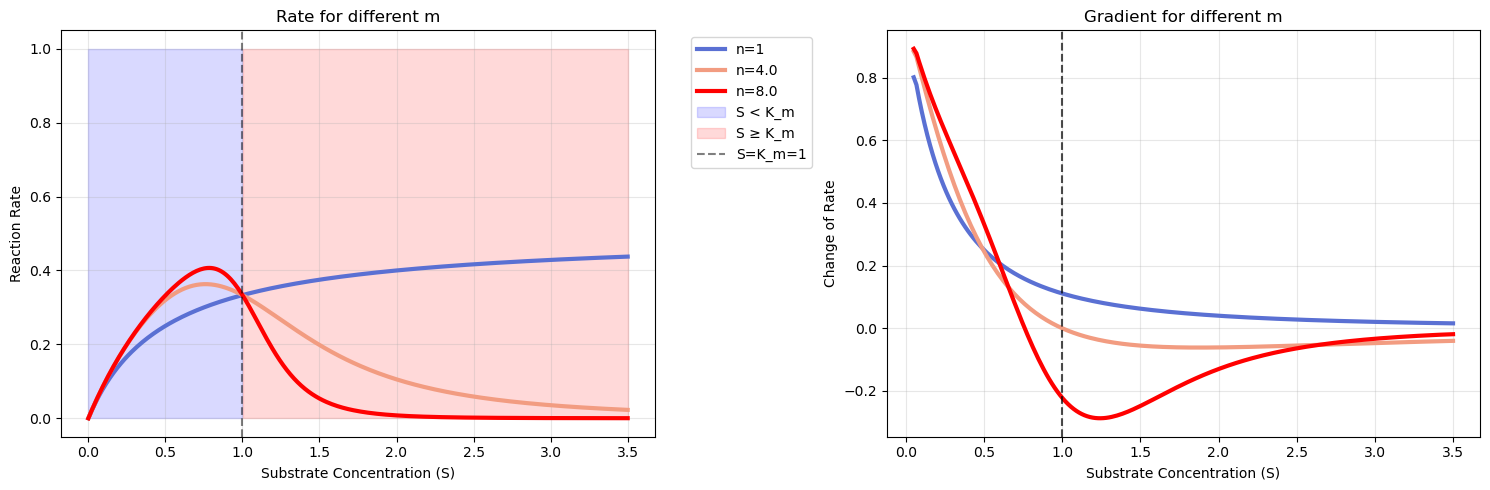

In [36]:
# Parameters
K_m   = 1
k_max = 1
k_i   = 1

# Shared colormap: royalblue → lightsalmon → red over the full n range
_cmap = LinearSegmentedColormap.from_list('hill', ['royalblue', 'lightsalmon', 'red'])

def m_to_color(m, m_min=0.5, m_max=8.0):
    """Return (r, g, b) floats in [0,1] for a given Hill coefficient n."""
    t = float((m - m_min) / (m_max - m_min))
    return _cmap(t)[:3]

def m_to_plotly_color(m, m_min=0.5, m_max=8.0):
    r, g, b = m_to_color(m, m_min, m_max)
    return f'rgb({int(r*255)},{int(g*255)},{int(b*255)})'

# Ranges for substrate and Hill coefficient
S_values = np.linspace(0,   3, 100)  
m_values = np.linspace(0.5, 4, 100)

# Meshgrid of S and n
S, M = np.meshgrid(S_values, m_values)

# Reaction rate and its gradient
rate_landscape = np.zeros_like(S)
for i in range(S.shape[0]):
    for j in range(S.shape[1]):
        rate_landscape[i,j] = haldane_kinetics(S[i,j], k_max, K_m, k_i, M[i,j])

rate_landscape_gradient = np.gradient(rate_landscape)


# Plot 1
fig = figure(figsize=(15, 5))

# 1. Impact of cooperativity on reaction rate
ax1 = fig.add_subplot(1, 2, 1)

S_fine = np.linspace(0, 3.5, 300)
m_transition = [1, 4.0, 8.0]
colors = [m_to_color(m) for m in m_transition]

for m, color in zip(m_transition, colors):
    rate = haldane_kinetics(S_fine, k_max, K_m, k_i, m)
    ax1.plot(S_fine, rate, color=color, linewidth=3, label=f'n={m}')

# Annotations
ax1.fill_between(S_fine, 0, 1, where=(S_fine<1),  alpha=0.15, color='blue', label='S < K_m')
ax1.fill_between(S_fine, 0, 1, where=(S_fine>=1), alpha=0.15, color='red', label='S ≥ K_m')
ax1.axvline(x=1, color='black', linestyle='--', alpha=0.5, label='S=K_m=1')

ax1.set_xlabel('Substrate Concentration (S)')
ax1.set_ylabel('Reaction Rate')
ax1.set_title('Rate for different m')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True, alpha=0.3)


# 2. Impact of cooperativity on derivative of reaction rate
ax2 = fig.add_subplot(1, 2, 2)

S_analysis = np.linspace(0.05, 3.5, 200)

for ind, m in enumerate([1.0, 2.0, 4.0]):
    rate = haldane_kinetics(S_analysis, k_max, K_m, k_i, m)
    derivative = np.gradient(rate, S_analysis)
    ax2.plot(S_analysis, derivative, label=f'm={m}', color=colors[ind], linewidth=3)

ax2.axvline(x=1, color='black', linestyle='--', alpha=0.7, label='S=K_m=1')
ax2.set_xlabel('Substrate Concentration (S)')
ax2.set_ylabel('Change of Rate')
ax2.set_title('Gradient for different m')
# ax2.legend()
ax2.grid(True, alpha=0.3)

fig.tight_layout()


# Print analysis
print("Enzyme Kinetics without and with cooperativity")
print("=" * 50)
print(f"Parameters: k_max = {k_max}, K_m = {K_m}")
print("\nKey observations:")
print("1. n = 1: Classic hyperbolic Michaelis-Menten kinetics")
print("2. n > 1: Positive cooperativity - sigmoidal curves")
print("3. n >> 1: Switch-like behavior - very steep transition")
print(f"5. Half-maximal rate at S = K_m = {K_m}")
print("\n Change from hyperbolic (blue) to switch-like shape (orange, red)")
print(' ')


The graphs show the rate function for three different values of the Hill coefficient. This illustrates how the rate behaves in the absence (n=1) or presence (n>1) of cooperativity. At high values of n the function approaches a step function. There is either a small rate (left of the dashed vertical line) or a high rate (to the right). In dynamical model this will lead to "switching" behaviour a reaction following such a rate law will mostly be either slow or fast. Iin a sense, this offers a smooth transition between an 'off' and an 'on' state.  


Note: the rate function (left) will always end at rate=1, independent of the Hill coefficient. Similarly the derivative (right) will always end at zero. 

## Two parameter view of the function

An extension of the above code lets us go from a single line which is evaluated at different values of n to a two-dimensional plane: we can evaluate the function for a range of S and a range of n simultaneously and plot the two-dimenstional result as a heat map.

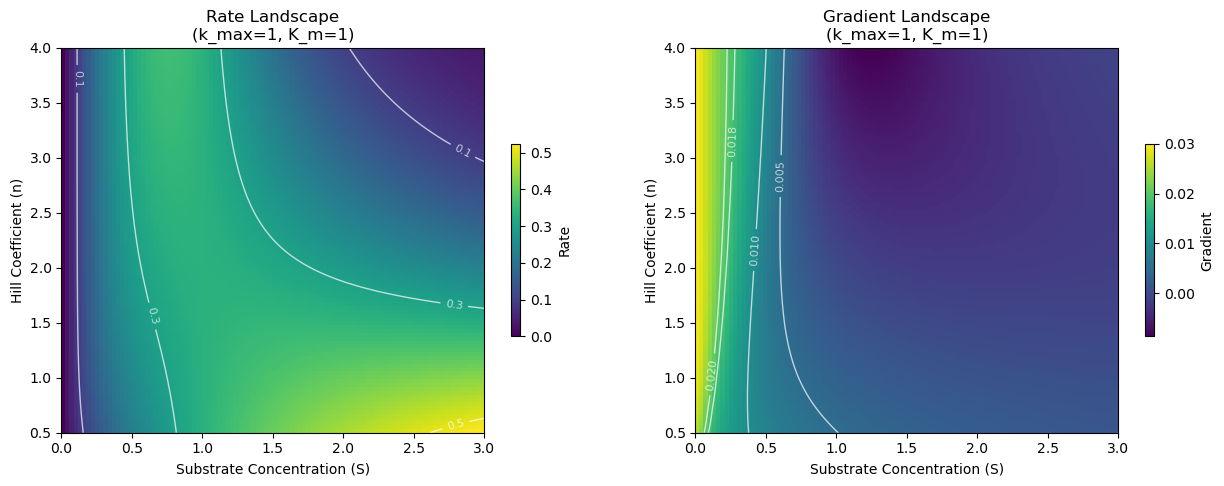

In [31]:
# Plot 2
fig = figure(figsize=(15, 5))

# 3. Rate Landscape (S vs n)
ax3 = fig.add_subplot(1, 2, 1)

im3 = ax3.imshow(rate_landscape, extent=[S_values.min(), S_values.max(), 
                                       m_values.min(), m_values.max()],
               origin='lower', aspect='auto', cmap='viridis')
ax3.set_xlabel('Substrate Concentration (S)')
ax3.set_ylabel('Hill Coefficient (n)')
ax3.set_title(f'Rate Landscape\n(k_max={k_max}, K_m={K_m})')

fig.colorbar(im3, ax=ax3, label='Rate', shrink=0.5)

contour_levels = [0.1, 0.3, 0.5, 0.7, 0.9]
contours = ax3.contour(S, M, rate_landscape, levels=contour_levels, 
                       colors='white', alpha=0.7, linewidths=1)
ax3.clabel(contours, inline=True, fontsize=8, fmt='%.1f')


# 4. Derivative of Rate Landscape
ax4 = fig.add_subplot(1, 2, 2)

im4 = ax4.imshow(rate_landscape_gradient[1], extent=[S_values.min(), S_values.max(), 
                                       m_values.min(), m_values.max()], vmax=0.03,
               origin='lower', aspect='auto', cmap='viridis')
ax4.set_xlabel('Substrate Concentration (S)')
ax4.set_ylabel('Hill Coefficient (n)')
ax4.set_title(f'Gradient Landscape\n(k_max={k_max}, K_m={K_m})')
fig.colorbar(im4, ax=ax4, label='Gradient', shrink=0.5)

# Add contour lines
contour_levels_gradient = [0.005, 0.01, 0.018, 0.02, 0.03]
contours_grad = ax4.contour(S, M, rate_landscape_gradient[1], levels=contour_levels_gradient, 
                       colors='white', alpha=0.7, linewidths=1)
ax4.clabel(contours_grad, inline=True, fontsize=8, fmt='%.3f');


This two-dimensional heat map helps to imagine the overall rate landscape. The above line plots are horizontal cuts through this it. Note how the transtion from hhyperbolic to sigmoidal leads to an increase on the darkblue region in the rate law (left) and an increase of the bright yellow region (right). The derivative on the right is more complex in that it has two maxima (bright yellow) and a saddle like sdip between them for coefficients between 1.5 and 2. It is also evident that for substrate concentrations above two times the Km (which is 1 in our case), the  change of rate is only small. 

# Interactive Slider widget

Use this interactive plot to see how the line graphs of the rate and its derivative change simultaneously. See if you get an intuition for the correspondence between the line graphs and the two-dimensional landscape above. Press the play button to go through the range of coefficient values continuously. Use the mouse curser to adjust any value manually. The biggest change is seen between 0.5 and 2. 

At very small substrate concentrations, the derivative reaches very high values and extends beyond the fixed coordinate vertical axis. 


In [32]:
import plotly.graph_objects as go


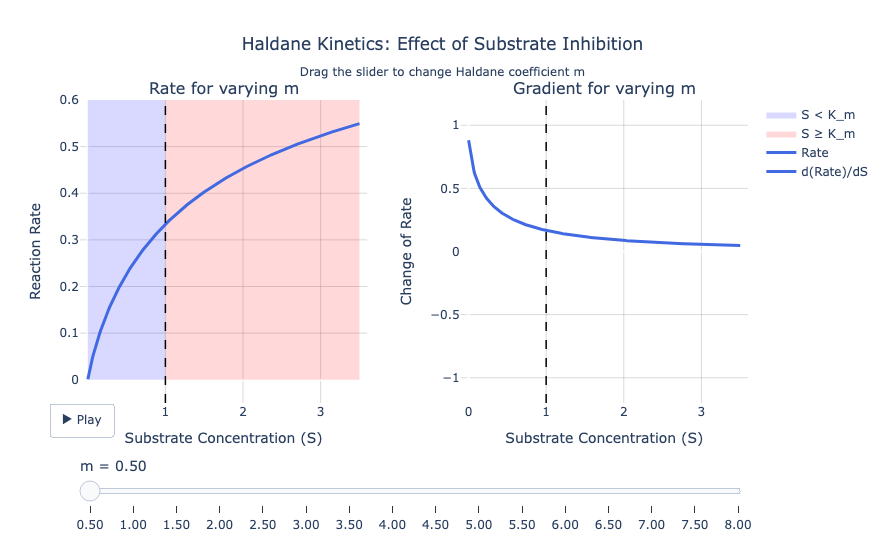

In [35]:
from plotly.subplots import make_subplots

S_values = np.linspace(0.001, 3.5, 300)
S_left   = np.linspace(0, 1,   100)
S_right  = np.linspace(1, 3.5, 150)

m_animation = np.linspace(0.5, 8.0, 16)

# ── subplots ──────────────────────────────────────────────────────────────────
fig_animation = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Rate for varying m', 'Gradient for varying m'),
    horizontal_spacing=0.14
)

# ── trace 0: blue fill S < K_m (left subplot) ─────────────────────────────────
fig_animation.add_trace(go.Scatter(
    x=np.concatenate([S_left, S_left[::-1]]),
    y=np.concatenate([np.ones(100), np.zeros(100)]),
    fill='toself',
    fillcolor='rgba(0,0,255,0.15)',
    line=dict(color='rgba(0,0,0,0)'),
    name='S < K_m',
    hoverinfo='skip'
), row=1, col=1)

# ── trace 1: red fill S >= K_m (left subplot) ──────────────────────────────────
fig_animation.add_trace(go.Scatter(
    x=np.concatenate([S_right, S_right[::-1]]),
    y=np.concatenate([np.ones(150), np.zeros(150)]),
    fill='toself',
    fillcolor='rgba(255,0,0,0.15)',
    line=dict(color='rgba(0,0,0,0)'),
    name='S \u2265 K_m',
    hoverinfo='skip'
), row=1, col=1)

# ── trace 2: animated Haldane function (left subplot) ───────────────────────────
m_init     = m_animation[0]
rate_init  = haldane_kinetics(S_values, k_max, K_m, k_i, m_init)
deriv_init = np.gradient(rate_init, S_values)

fig_animation.add_trace(go.Scatter(
    x=S_values, y=rate_init,
    mode='lines',
    line=dict(color=n_to_plotly_color(m_init), width=3),
    name='Rate'
), row=1, col=1)

# ── trace 3: animated derivative (right subplot) ──────────────────────────────
fig_animation.add_trace(go.Scatter(
    x=S_values, y=deriv_init,
    mode='lines',
    line=dict(color=n_to_plotly_color(m_init), width=3),
    name='d(Rate)/dS'
), row=1, col=2)

# ── frames: update traces 2 & 3 together ─────────────────────────────────────
frames = []
for m_val in m_animation:
    rate  = haldane_kinetics(S_values, k_max, K_m, k_i, m_val)
    deriv = np.gradient(rate, S_values)
    frames.append(go.Frame(
        data=[
            go.Scatter(x=S_values, y=rate,  mode='lines', line=dict(color=n_to_plotly_color(m_val), width=3)),
            go.Scatter(x=S_values, y=deriv, mode='lines', line=dict(color=n_to_plotly_color(m_val), width=3))
        ],
        traces=[2, 3],
        name=f"m={m_val:.2f}"
    ))

fig_animation.frames = frames

# ── layout ────────────────────────────────────────────────────────────────────
fig_animation.update_layout(
    title=dict(
        text="Haldane Kinetics: Effect of Substrate Inhibition"
             "<br><sub>Drag the slider to change Haldane coefficient m</sub>",
        x=0.5
    ),
    width=1050,
    height=540,
    plot_bgcolor='white',
    legend=dict(x=1.02, y=1, xanchor='left'),
    shapes=[
        dict(type='line', x0=1, x1=1, y0=0, y1=1,
             xref='x',  yref='y domain',
             line=dict(color='black', dash='dash', width=1.5)),
        dict(type='line', x0=1, x1=1, y0=0, y1=1,
             xref='x2', yref='y2 domain',
             line=dict(color='black', dash='dash', width=1.5)),
    ],
    updatemenus=[dict(
        type='buttons',
        showactive=False,
        y=0,
        x=0.05,
        xanchor='right',
        buttons=[dict(
            label='\u25b6 Play',
            method='animate',
            args=[None, {'frame': {'duration': 100, 'redraw': True}, 'fromcurrent': True}]
        )]
    )],
    sliders=[dict(
        currentvalue=dict(prefix='m = ', font=dict(size=14)),
        pad=dict(t=50),
        steps=[dict(
            method='animate',
            args=[[f"n={m_val:.2f}"],
                  {'mode': 'immediate',
                   'frame': {'duration': 100, 'redraw': True},
                   'transition': {'duration': 0}}],
            label=f"{m_val:.2f}"
        ) for m_val in m_animation]
    )]
)

# axes styling to match static plot
grid_style = dict(gridcolor='rgba(0,0,0,0.15)', showgrid=True, gridwidth=1)

fig_animation.update_xaxes(title_text='Substrate Concentration (S)',
                            range=[-0.1, 3.6], **grid_style, row=1, col=1)
fig_animation.update_xaxes(title_text='Substrate Concentration (S)',
                            range=[-0.1, 3.6], **grid_style, row=1, col=2)
fig_animation.update_yaxes(title_text='Reaction Rate',
                            range=[-0.05, 0.6], **grid_style, row=1, col=1)
fig_animation.update_yaxes(title_text='Change of Rate',
                            range=[-1.2, 1.2], **grid_style, row=1, col=2)

fig_animation.show()
